# Project 6: Synthesis — BIND as a learned response operator

The goal here is to generate observations and take the derivatives of them with respect to parameters. So we need 
1. a differentiable sampling of the field
2. a differentiable generation of the observable from the field
3. the gradient of the observable with respect to parameters

## Imports

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from matplotlib.colors import TwoSlopeNorm
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

# torch.func (functorch) — available in PyTorch ≥ 2.0
from torch.func import jacrev, vmap

ROOT = Path('.').resolve()
sys.path.insert(0, str(ROOT))
from metrics import radial_profile  # noqa: E402

## Constants & configuration

In [2]:
# ── toggle ────────────────────────────────────────────────────────────────────
REBUILD = False   # set True to recompute the OBS_HPV cube from scratch

# ── paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR = ROOT / 'analysis_physics_cache'
FIG_DIR   = ROOT / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)

MODEL_NAME   = 'fm_two_head'
PROJ5_CACHE  = CACHE_DIR / f'proj5_marginals_{MODEL_NAME}.npz'
PROJ4_CACHE  = CACHE_DIR / f'proj4_pairs_v2_{MODEL_NAME}.npz'
BASE_CACHE   = CACHE_DIR / f'halo_features_{MODEL_NAME}.npz'
PROJ6_CACHE  = CACHE_DIR / f'proj6_synthesis_{MODEL_NAME}.npz'

PARAM_META_CSV = '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
SUITE_ROOT     = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP, MASS_TAG = 'snap_090', 'mass_threshold_1p000e13'

# ── model checkpoint for autograd Jacobian ────────────────────────────────────
RUN_DIR = Path('/mnt/home/mlee1/ceph/fm_runs') / MODEL_NAME
CKPT    = RUN_DIR / 'checkpoints' / 'last.ckpt'

# ── dimensions ────────────────────────────────────────────────────────────────
N_PARAMS  = 35
N_GRID    = 7
PATCH_PIX = 128
N_RBINS   = 32
FID_IDX   = 3   # central index of the 7-point grid

# ── matplotlib ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
    'figure.dpi': 110, 'savefig.bbox': 'tight',
})

# ── pretty labels ─────────────────────────────────────────────────────────────
PRETTY = {
    0: r'$\Omega_m$', 1: r'$\sigma_8$',
    2: r'$A_{\rm SN1}$', 3: r'$A_{\rm AGN1}$',
    4: r'$A_{\rm SN2}$', 5: r'$A_{\rm AGN2}$',
    6: r'$\Omega_b$', 7: r'$h$', 8: r'$n_s$',
    9: r'$\tau_{\rm SFR}$', 10: r'$f_{\rm EQS}$', 11: r'$\alpha_{\rm IMF}$',
    12: r'$M_{\rm SNII}$', 13: r'$f_{\rm therm}$',
    14: r'$p_{\rm wind}$', 15: r'$\rho_{\rm wind}$', 16: r'$v_{w,\min}$',
    17: r'$\eta_{\rm w,Z}$', 18: r'$Z_{w,0}$', 19: r'$\alpha_{w,Z}$',
    20: r'$f_{\rm dump}$', 21: r'$M_{\rm seed}$', 22: r'$f_{\rm Bondi}$',
    23: r'$f_{\rm Edd}$', 24: r'$\epsilon_{\rm therm}$', 25: r'$\epsilon_r$',
    26: r'$\chi_{\rm crit}$', 27: r'$\alpha_Q$',
    28: r'$\beta_{\rm UV}$', 29: r'$\Delta z_{\rm UV}$',
    30: r'$\beta_{\rm HeII}$', 31: r'$\Delta z_{\rm HeII}$',
    32: r'$R_{\rm Ia}$', 33: r'$\alpha_{\rm Ia}$', 34: r'$\epsilon_{\rm soft}$',
}

PARAM_GROUP = {}
for j in range(N_PARAMS):
    if j in (0, 1, 6, 7, 8):
        PARAM_GROUP[j] = 'cosmo'
    elif j in (2, 4) or j in range(9, 21):
        PARAM_GROUP[j] = 'SN'
    elif j in (3, 5) or j in range(21, 28):
        PARAM_GROUP[j] = 'AGN'
    else:
        PARAM_GROUP[j] = 'other'

GROUP_COLORS = {'cosmo': '#1f77b4', 'SN': '#ff7f0e',
                'AGN': '#d62728', 'other': '#7f7f7f'}

## Observable names

In [3]:
OBS_NAMES = [
    'M_star', 'M_gas', 'f_gas',
    'sigma_gas_central', 'compact_star',
    'compact_DM', 'q_DM', 'q_star',
]
OBS_LABELS = {
    'M_star':            r'$M_\star$',
    'M_gas':             r'$M_{\rm gas}$',
    'f_gas':             r'$f_{\rm gas}$',
    'sigma_gas_central': r'$\Sigma_{\rm gas,c}$',
    'compact_star':      r'$c_\star$',
    'compact_DM':        r'$c_{\rm DM}$',
    'q_DM':              r'$q_{\rm DM}$',
    'q_star':            r'$q_\star$',
}

In [4]:
halo_catalog = np.load('/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_0/snap_090/mass_threshold_1p000e13/halo_catalog.npz')
halo_cutouts = np.load('/mnt/home/mlee1/ceph/fm_testsuite/CV/sim_0/snap_090/mass_threshold_1p000e13/halo_cutouts.npz')
params = halo_catalog['params']  # (N_halos, N_params)
params[:, 14] = 0

In [5]:
## Load model

In [6]:
import torch
from train import FlowMatchingLit
from data import NormStats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lit = FlowMatchingLit.load_from_checkpoint(str(CKPT), map_location=device)
lit.eval()
del lit.ema  # safety: prevent accidental EMA application

model_fm = lit.fm
model_fm.model.eval()
print(f'Loaded {CKPT.name} on {device}')
print(f'out_channels = {model_fm.out_channels}')


/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loaded last.ckpt on cuda
out_channels = 4


In [7]:
# Normalize params using the same pipeline as AstroDataset._normalize_params.
norm_stats = NormStats.load(RUN_DIR / 'norm_stats.npz')

raw = params.astype(np.float32)  # (N_halos, 35) from halo_catalog

_p = np.where(
    norm_stats.param_log_flag == 1,
    np.log10(np.maximum(raw, 1e-30)),
    raw,
)
_rang = norm_stats.param_max - norm_stats.param_min
params_norm = (_p - norm_stats.param_min) / (_rang + 1e-8)  # (N_halos, 35) in [0,1]

print(f'params_norm shape : {params_norm.shape}')
print(f'params_norm[0,:6] : {params_norm[0, :6].round(3)}')


params_norm shape : (55, 35)
params_norm[0,:6] : [0.5 0.5 0.5 0.5 0.5 0.5]


In [8]:
# ── pick a subset of halos ────────────────────────────────────────────────────
N_HALOS = 4   # number of halos to visualise / differentiate

from data import log_transform  # log10(1 + x)

cond_np_raw = halo_cutouts['condition'][:N_HALOS]      # (N, 128, 128)  — raw pixel values
ls_np_raw   = halo_cutouts['large_scale'][:N_HALOS]    # (N, 3, 128, 128) — raw

# Normalize: mirror pipeline.py exactly
#   cond:        log10(1+x) → z-score with cond_mean / cond_std
#   large_scale: log10(1+x) → z-score with ls_mean / ls_std  (per-channel)
cond_np = (log_transform(cond_np_raw) - norm_stats.cond_mean) / (norm_stats.cond_std + 1e-8)
ls_np   = (log_transform(ls_np_raw)   - norm_stats.ls_mean[:, None, None]) / (norm_stats.ls_std[:, None, None] + 1e-8)
p_norm  = params_norm[:N_HALOS]   # (N, 35) — already normalized in cell 11

# tensors on device
cond_t = torch.tensor(cond_np[:, np.newaxis], dtype=torch.float32, device=device)  # (N,1,128,128)
ls_t   = torch.tensor(ls_np,                  dtype=torch.float32, device=device)  # (N,3,128,128)
p_t    = torch.tensor(p_norm,                 dtype=torch.float32, device=device)  # (N,35)

# verify shapes and ranges look sane
print(f'cond range : [{cond_np.min():.2f}, {cond_np.max():.2f}]  (expect ~[-3, 3])')
print(f'ls   range : [{ls_np.min():.2f}, {ls_np.max():.2f}]')

# ── generate maps ─────────────────────────────────────────────────────────────
with torch.no_grad():
    sample_check = model_fm.sample(cond_t, ls_t, p_t, n_steps=50)

C = sample_check.shape[1]  # 3 or 4 (two-head)
# Model channel order: ch0=DM, ch1=gas, ch2=occ, ch3=stars_cond
CHANNEL_NAMES = ['DM', 'gas', 'stars'] if C == 3 else ['DM', 'gas', 'occ', 'stars_cond']
print(f'Generated maps: {tuple(sample_check.shape)}  channels={CHANNEL_NAMES}')


cond range : [-1.99, 5.65]  (expect ~[-3, 3])
ls   range : [-2.01, 6.03]
Generated maps: (4, 4, 128, 128)  channels=['DM', 'gas', 'occ', 'stars_cond']


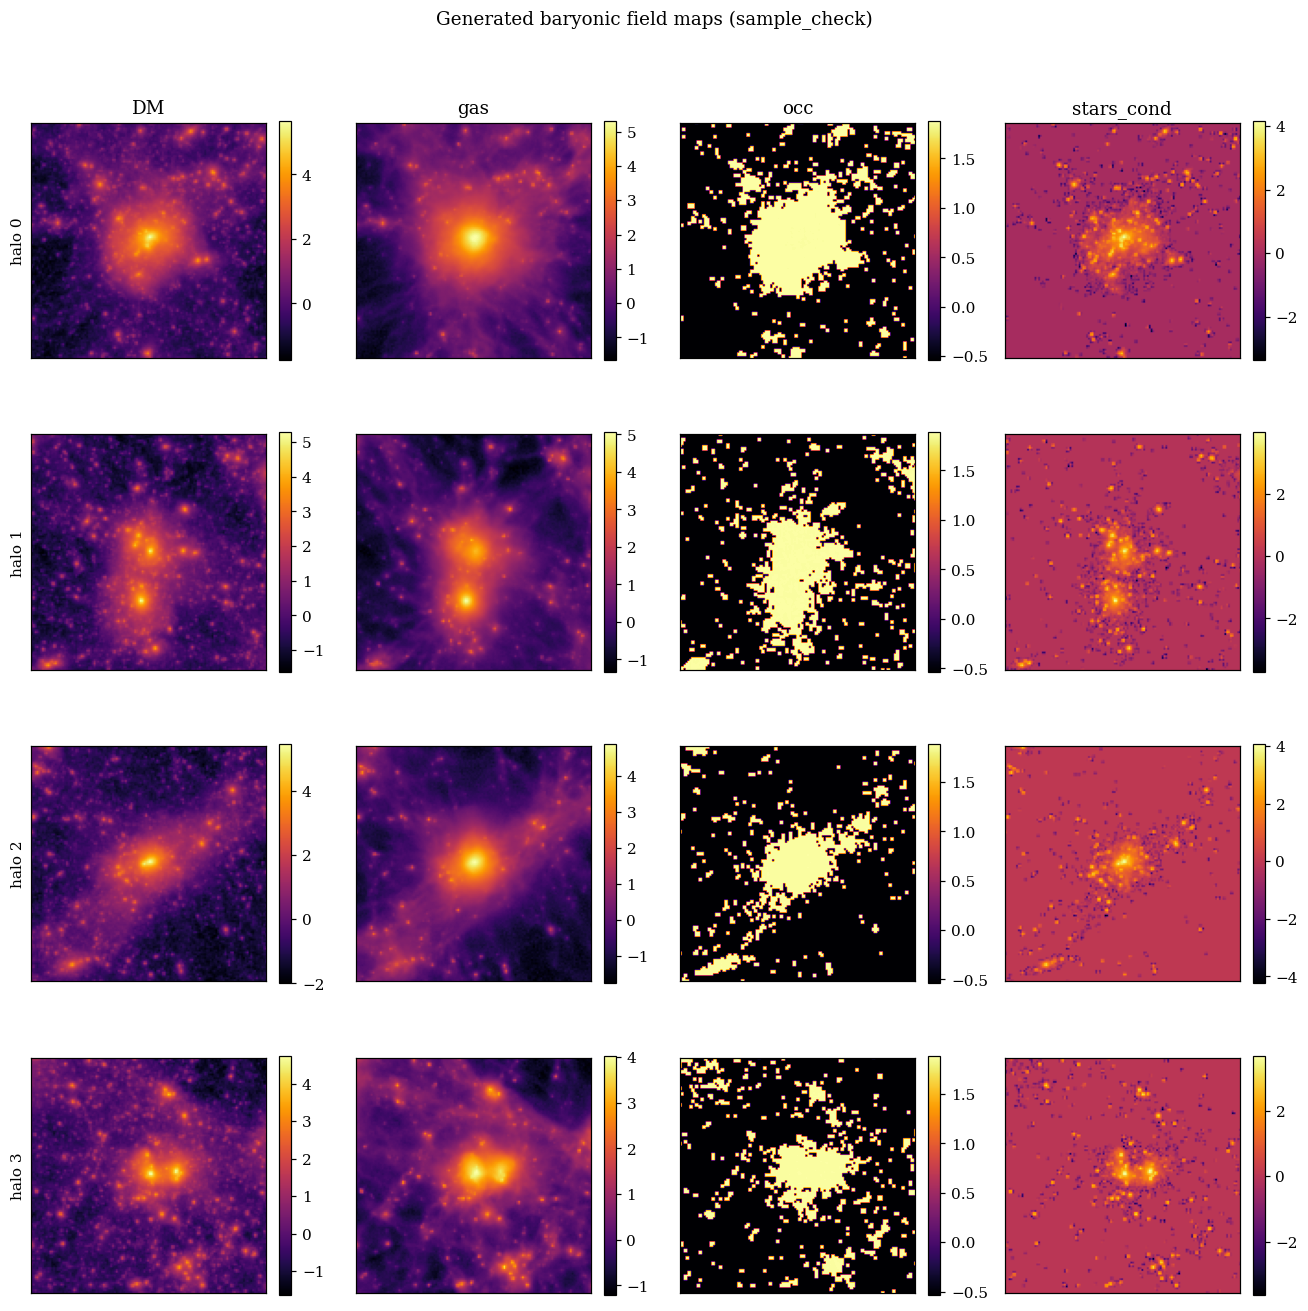

In [9]:
# ── visualise generated maps ──────────────────────────────────────────────────
fig, axes = plt.subplots(N_HALOS, C, figsize=(3 * C, 3 * N_HALOS))
maps_np = sample_check.cpu().numpy()

for hi in range(N_HALOS):
    for ci in range(C):
        ax = axes[hi, ci] if N_HALOS > 1 else axes[ci]
        im = ax.imshow(maps_np[hi, ci], origin='lower', cmap='inferno')
        plt.colorbar(im, ax=ax, fraction=0.046)
        if hi == 0:
            ax.set_title(CHANNEL_NAMES[ci])
        ax.set_ylabel(f'halo {hi}') if ci == 0 else None
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Generated baryonic field maps (sample_check)', y=1.01)
plt.tight_layout()
plt.show()


## Jacobian: d(field) / d(params)

For each halo we:
1. Enable `requires_grad` on the (1, 35) params tensor
2. Run `model_fm.sample(..., grad=True)` — the ODE loop now carries gradients
3. Compute the Jacobian of the per-channel spatial mean w.r.t. all 35 params

Result: `J` has shape **(N_halos, C, 35)** — how each channel's mean field value responds to each cosmological / astrophysical parameter.

In [19]:
N_STEPS_GRAD = 20   # fewer steps keeps memory manageable; increase for precision

J_list = []  # (N_halos, C, 35)

for hi in range(N_HALOS):
    cond_h = cond_t[hi : hi + 1]   # (1, 1, H, W)
    ls_h   = ls_t[hi : hi + 1]     # (1, 3, H, W)

    p_h = p_t[hi : hi + 1].detach().clone().requires_grad_(True)  # (1, 35)

    # grad-enabled sampling — ODE runs under torch.enable_grad()
    x_gen = model_fm.sample(cond_h, ls_h, p_h, n_steps=N_STEPS_GRAD, grad=True)
    # x_gen: (1, C, H, W)

    # Summarise each channel by its spatial mean — shape (C,)
    channel_means = x_gen[0].mean(dim=(-2, -1))  # (C,)

    # Jacobian row by row (one backward pass per channel)
    jac_rows = []
    for c in range(C):
        grad_c, = torch.autograd.grad(
            channel_means[c], p_h,
            retain_graph=(c < C - 1),
        )
        jac_rows.append(grad_c[0].detach().cpu().numpy())  # (35,)

    J_list.append(np.stack(jac_rows, axis=0))   # (C, 35)
    print(f'halo {hi} done')

J = np.stack(J_list, axis=0)   # (N_halos, C, 35)
print(f'Jacobian shape: {J.shape}  (N_halos, C, N_params)')


halo 0 done
halo 1 done
halo 2 done
halo 3 done
Jacobian shape: (4, 4, 35)  (N_halos, C, N_params)


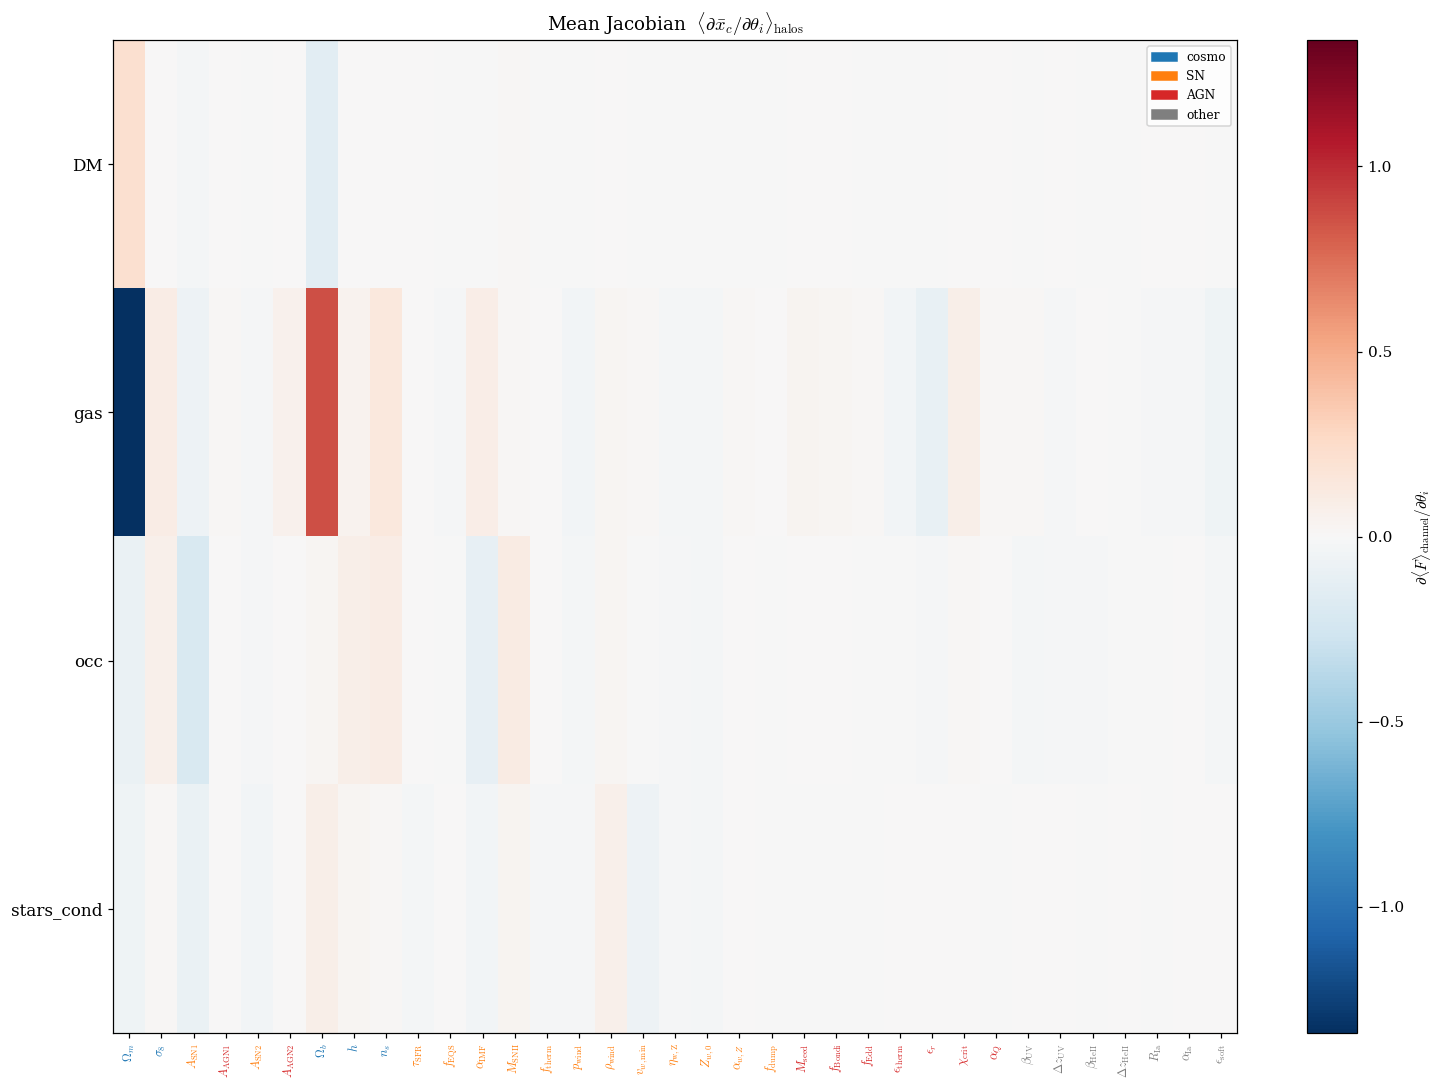

In [20]:
# ── heatmap: mean Jacobian (averaged over halos) ──────────────────────────────
J_mean = J.mean(axis=0)   # (C, 35)

param_labels = [PRETTY.get(i, str(i)) for i in range(N_PARAMS)]
group_colors_list = [GROUP_COLORS[PARAM_GROUP[i]] for i in range(N_PARAMS)]

fig, ax = plt.subplots(figsize=(14, 2.5 * C))
vmax = np.abs(J_mean).max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(J_mean, aspect='auto', cmap='RdBu_r', norm=norm)

ax.set_yticks(range(C))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=11)
ax.set_xticks(range(N_PARAMS))
ax.set_xticklabels(param_labels, rotation=90, fontsize=8)

# colour the x-tick labels by parameter group
for tick, col in zip(ax.get_xticklabels(), group_colors_list):
    tick.set_color(col)

plt.colorbar(im, ax=ax, label=r'$\partial \langle F \rangle_{\rm channel} / \partial \theta_i$')
ax.set_title('Mean Jacobian  $\\langle \\partial \\bar{x}_c / \\partial \\theta_i \\rangle_{\\rm halos}$')

# legend for group colours
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k, v in GROUP_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.show()


In [16]:
# ── pixel-wise Jacobian via finite differences with fixed noise ───────────────
HALO_IDX    = 0
PARAMS_SHOW = [0, 1, 2, 3, 4, 5]   # Omega_m, sigma_8, A_SN1, A_AGN1, A_SN2, A_AGN2
FD_EPS      = 1e-3    # step in normalised param space (central differences)
N_STEPS_FD  = 50

H, W = PATCH_PIX, PATCH_PIX
cond_h = cond_t[HALO_IDX : HALO_IDX + 1]
ls_h   = ls_t[HALO_IDX : HALO_IDX + 1]
p_base = p_t[HALO_IDX : HALO_IDX + 1].detach()

# ── deterministic sampler with fixed noise ────────────────────────────────────
def _sample_fixed_noise(model_fm, cond, ls, params, noise, n_steps):
    """FM Euler integration with a pre-supplied initial noise tensor.
    Purely deterministic in params — required for reliable FD."""
    x = noise.clone()
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((cond.shape[0],), i * dt, device=cond.device)
        inp = torch.cat([x, cond, ls], dim=1)
        v = model_fm.model(inp, t, params)
        x = x + v * dt
    return x   # (B, C, H, W)

# Pre-generate the noise once
torch.cuda.manual_seed(42)
z_fixed = torch.randn(1, model_fm.out_channels, H, W, device=device)

pixel_jac_cols = []   # will hold (C, H, W) per param

with torch.no_grad():
    x_base = _sample_fixed_noise(model_fm, cond_h, ls_h, p_base, z_fixed, N_STEPS_FD)

    for j in range(N_PARAMS):
        # central differences: (f(p+eps) - f(p-eps)) / (2*eps)
        p_plus  = p_base.clone(); p_plus[0, j]  += FD_EPS
        p_minus = p_base.clone(); p_minus[0, j] -= FD_EPS

        x_plus  = _sample_fixed_noise(model_fm, cond_h, ls_h, p_plus,  z_fixed, N_STEPS_FD)
        x_minus = _sample_fixed_noise(model_fm, cond_h, ls_h, p_minus, z_fixed, N_STEPS_FD)

        col = ((x_plus - x_minus) / (2 * FD_EPS))[0].cpu().numpy()  # (C, H, W)
        pixel_jac_cols.append(col)

        if (j + 1) % 7 == 0 or j == N_PARAMS - 1:
            print(f'  param {j+1}/{N_PARAMS} done')

pixel_jac_np = np.stack(pixel_jac_cols, axis=-1)   # (C, H, W, N_PARAMS) in normalized units
print(f'pixel_jac_np shape: {pixel_jac_np.shape}  (normalized units)')

# ── chain rule: normalized -> dL/dq where L = log10(1+field) and q is
#                (log10 p) for log-flagged params, raw p otherwise ────────────
if norm_stats.stars_two_head and C == 4:
    out_std = np.array([
        norm_stats.target_std[0],         # ch0 = DM (log10(1+DM))
        norm_stats.target_std[1],         # ch1 = gas (log10(1+gas))
        float(norm_stats.stars_occ_std),  # ch2 = occ_raw
        float(norm_stats.stars_cond_std), # ch3 = density_log
    ], dtype=np.float32)
else:
    out_std = norm_stats.target_std[:C].astype(np.float32)

rang = (norm_stats.param_max - norm_stats.param_min + 1e-8).astype(np.float32)

pixel_jac_dL_dq = (
    pixel_jac_np
    * out_std[:, None, None, None]
    / rang[None, None, None, :]
)
print(f'pixel_jac_dL_dq shape: {pixel_jac_dL_dq.shape}')
print('Units: d[log10(1+field_c)] / d[q_j], with q_j=log10(p_j) for log-flagged params and q_j=p_j otherwise')

# ── convert to dL/dlog10(p) for *all* params ──────────────────────────────────
# For log-flagged params: q_j = log10(p_j), factor = 1.
# For linear params: q_j = p_j, so dq_j/dlog10(p_j) = p_j * ln(10).
p_raw_ref = params[HALO_IDX].astype(np.float32)  # raw (not normalized) halo params
dq_dlogp = np.where(
    norm_stats.param_log_flag == 1,
    np.ones_like(p_raw_ref, dtype=np.float32),
    p_raw_ref * np.log(10.0),
).astype(np.float32)

pixel_jac_logparam = pixel_jac_dL_dq * dq_dlogp[None, None, None, :]
print(f'pixel_jac_logparam shape: {pixel_jac_logparam.shape}')
print('Units: d[log10(1+field_c)] / d[log10(p_j)]')

bad = np.where((norm_stats.param_log_flag == 0) & (p_raw_ref <= 0))[0]
if bad.size:
    print(f'Warning: {bad.size} linear params have p_j <= 0 at this halo; d/dlog10(p_j) is not defined there.')

  param 7/35 done
  param 14/35 done
  param 21/35 done
  param 28/35 done
  param 35/35 done
pixel_jac_np shape: (4, 128, 128, 35)  (normalized units)
pixel_jac_dL_dq shape: (4, 128, 128, 35)
Units: d[log10(1+field_c)] / d[q_j], with q_j=log10(p_j) for log-flagged params and q_j=p_j otherwise
pixel_jac_logparam shape: (4, 128, 128, 35)
Units: d[log10(1+field_c)] / d[log10(p_j)]


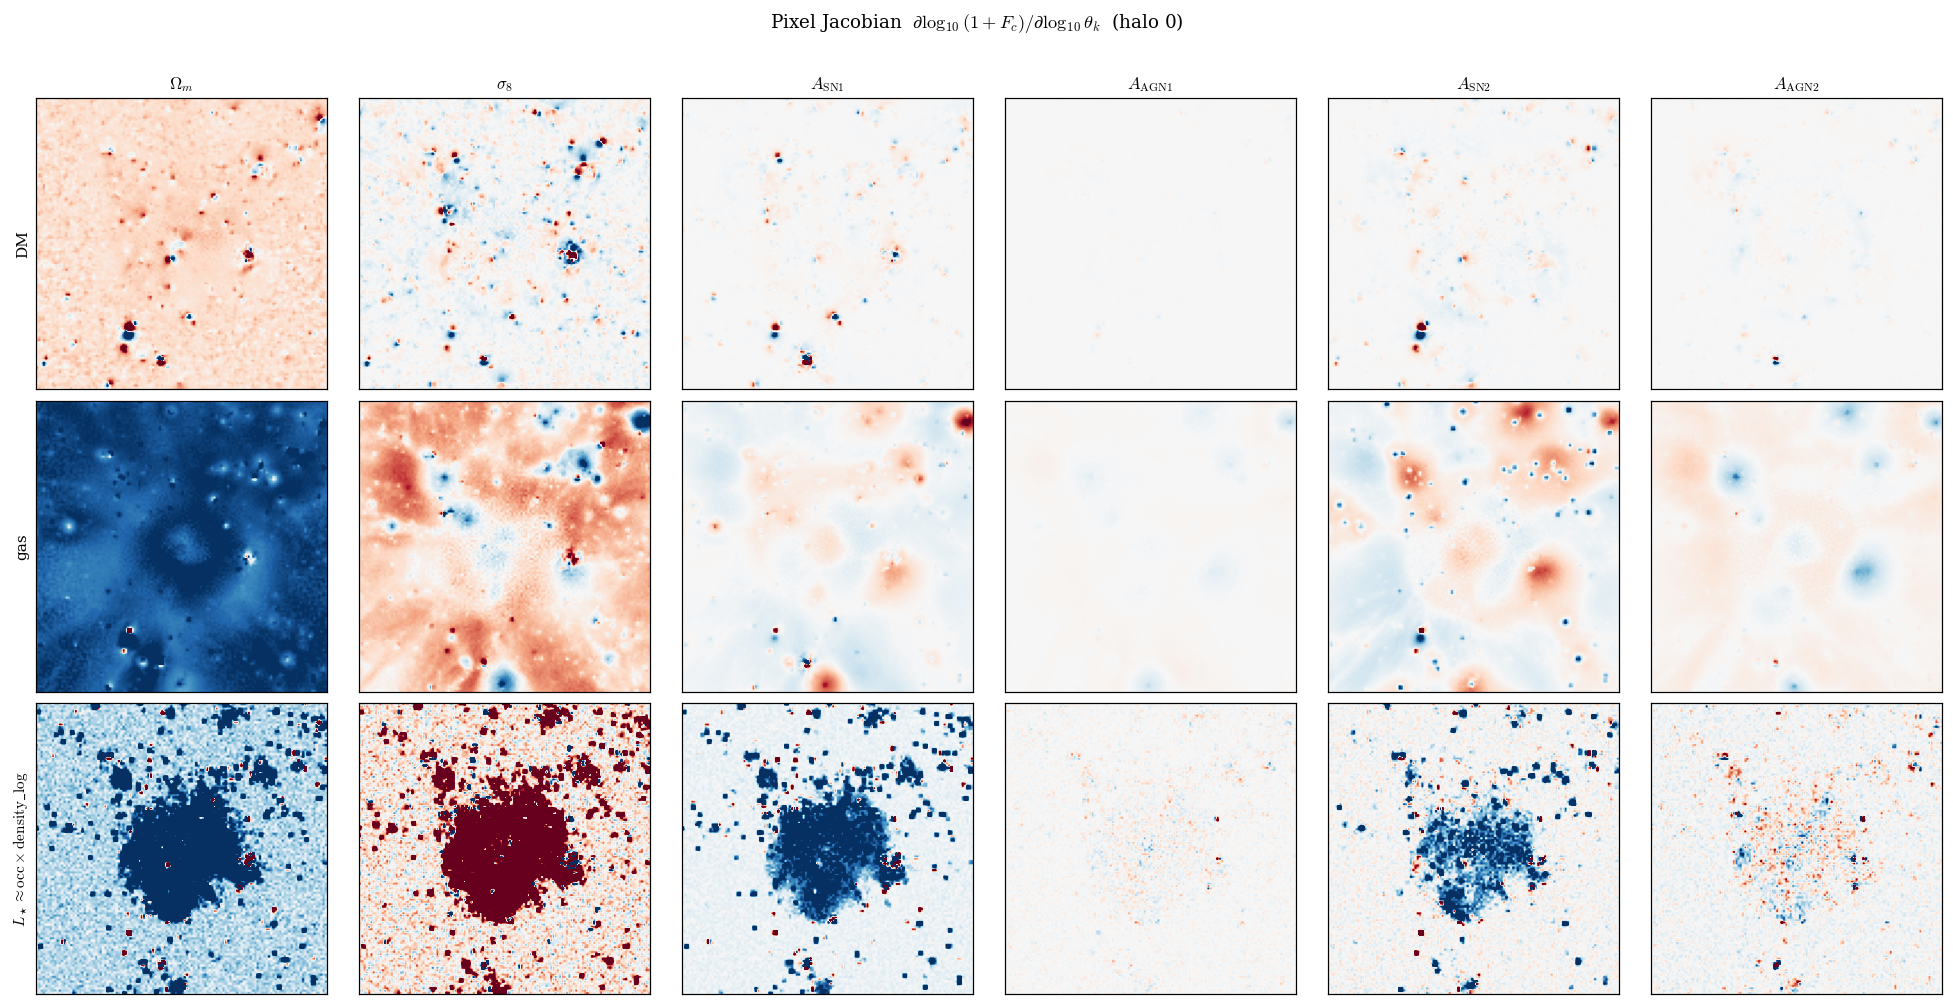

In [18]:
# ── visualise pixel-wise sensitivity maps: dlog(1+map) / dlog(param) ──────────
# Model channel order: ch0=DM, ch1=gas, ch2=occ, ch3=stars_cond
if norm_stats.stars_two_head and C == 4:
    # Convert the base sample from normalized two-head outputs to physical head units
    occ_raw_base = (
        x_base[0, 2].cpu().numpy() * float(norm_stats.stars_occ_std)
        + float(norm_stats.stars_occ_mean)
    )   # (H, W)
    density_log_base = (
        x_base[0, 3].cpu().numpy() * float(norm_stats.stars_cond_std)
        + float(norm_stats.stars_cond_mean)
    )   # (H, W)

    # L_star ~= occ_raw * density_log  (exact if occ_raw is binary 0/1)
    # dL_star/dtheta = density_log * d(occ_raw)/dtheta + occ_raw * d(density_log)/dtheta
    jac_stars = (
        density_log_base[:, :, None] * pixel_jac_logparam[2]
        + occ_raw_base[:, :, None]   * pixel_jac_logparam[3]
    )   # (H, W, N_PARAMS)

    pixel_jac_show = np.concatenate([
        pixel_jac_logparam[0:1],
        pixel_jac_logparam[1:2],
        jac_stars[None],
    ], axis=0)  # (3, H, W, N_PARAMS)
    channel_names_show = [CHANNEL_NAMES[0], CHANNEL_NAMES[1], r'$L_\star \approx {\rm occ}\times{\rm density\_log}$']
else:
    pixel_jac_show = pixel_jac_logparam
    channel_names_show = list(CHANNEL_NAMES)

n_rows = pixel_jac_show.shape[0]
n_show = len(PARAMS_SHOW)
fig, axes = plt.subplots(n_rows, n_show, figsize=(3 * n_show, 3 * n_rows))

for ci in range(n_rows):
    for pi, pidx in enumerate(PARAMS_SHOW):
        ax = axes[ci, pi] if n_rows > 1 else axes[pi]
        sens = pixel_jac_show[ci, :, :, pidx]
        vmax = np.abs(sens).max() + 1e-12
        ax.imshow(sens, origin='lower', cmap='RdBu_r',
                  vmin=-1, vmax=1)
        if ci == 0:
            ax.set_title(PRETTY.get(pidx, str(pidx)), fontsize=11)
        if pi == 0:
            ax.set_ylabel(channel_names_show[ci], fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    f'Pixel Jacobian  $\\partial \\log_{{10}}(1+F_c) / \\partial \\log_{{10}} \\theta_k$'
    f'  (halo {HALO_IDX})',
    y=1.01,
)
plt.tight_layout()
plt.show()

## Physical observables & their derivatives

For each generated halo we now derive scalar physical observables from the
denormalized maps and finite-difference them against the 35 parameters using
the same fixed-noise sampler `_sample_fixed_noise` defined above.

The observables, all computed within R200c (or as ratios thereof):
- `M_dm`, `M_gas`, `M_star` — projected mass inside circular aperture R200c
- `f_b` — baryon fraction (M_gas+M_star)/(M_dm+M_gas+M_star), and the cosmic-normalized version `f_b / f_b_cosmic` with `f_b_cosmic = Ω_b / Ω_m`
- `R_closure / R200c` — smallest R where f_b/f_b_cosmic ≥ 0.9 (NaN if never)
- `q_DM`, `q_gas`, `q_star` — 2D iterative-quadrupole axis ratios at R200c
- `dq_DM = q_DM_hydro − q_DM_DMO` — Chua+21 spherization back-reaction (DMO from `cond` is fixed in θ, so the derivative is `∂q_DM_hydro/∂θ`)


In [ ]:
# ── geometry constants (match project1/project2 conventions) ─────────────────
RHO_CRIT      = 2.775e11          # M_sun/h per (Mpc/h)^3
BOX_SIZE      = 50.0              # Mpc/h
N_PIX_FULL    = 1024
PATCH_BOX     = BOX_SIZE * PATCH_PIX / N_PIX_FULL    # 6.25 Mpc/h
MPC_PER_PIX   = PATCH_BOX / PATCH_PIX                # 0.04883 Mpc/h
OMEGA_B_FIXED = 0.049             # CAMELS holds Ω_b fixed
CLOSURE_THRESHOLD = 0.90

def r200c_mpc_h(m200c_msunh):
    return (3.0 * m200c_msunh / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0/3.0)

# ── radial-bin geometry: identical to metrics.radial_profile (n_bins=32) ─────
_yy, _xx = np.mgrid[:PATCH_PIX, :PATCH_PIX] - np.array([PATCH_PIX/2, PATCH_PIX/2])[:, None, None]
_RR_PIX  = np.sqrt(_xx**2 + _yy**2)
_NB      = 32
_BIN_EDGES_PIX = np.linspace(0, PATCH_PIX/2, _NB + 1)
_R_CENTRES_PIX = 0.5 * (_BIN_EDGES_PIX[:-1] + _BIN_EDGES_PIX[1:])
_BIN_MASKS  = [(_RR_PIX >= _BIN_EDGES_PIX[k]) & (_RR_PIX < _BIN_EDGES_PIX[k+1]) for k in range(_NB)]
_N_PIX_PER_BIN = np.array([m.sum() for m in _BIN_MASKS], dtype=np.float64)

def _radial_profile_2d(field_2d):
    """Mean field per annulus on the same grid as metrics.radial_profile."""
    return np.array([field_2d[m].mean() if c > 0 else 0.0
                     for m, c in zip(_BIN_MASKS, _N_PIX_PER_BIN)])

def aperture_sum(field_2d, r_pix):
    """Total mass in circular aperture of radius r_pix, centered on patch."""
    mask = _RR_PIX < r_pix
    return float(np.maximum(field_2d, 0.0)[mask].sum())

def axis_ratio_q(field_2d, r_aper_pix, max_iter=5, tol=1e-3, min_pixels=8):
    """Iterative mass-weighted 2D quadrupole axis ratio (q ∈ [0,1]).
    Mirrors project1_morphology.shape_in_aperture; returns q only."""
    H, W = field_2d.shape
    cx = (W - 1) / 2.0; cy = (H - 1) / 2.0
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float64)
    dx, dy = xx - cx, yy - cy
    f = field_2d.astype(np.float64)
    q, pa = 1.0, 0.0
    for _ in range(max_iter):
        c, s = np.cos(pa), np.sin(pa)
        x_rot =  c*dx + s*dy
        y_rot = -s*dx + c*dy
        a = r_aper_pix
        b = max(r_aper_pix * q, 1.0)
        mask = (x_rot/a)**2 + (y_rot/b)**2 < 1.0
        if mask.sum() < min_pixels:
            return np.nan
        w = np.where(mask, np.maximum(f, 0.0), 0.0)
        tot = w.sum()
        if tot <= 0:
            return np.nan
        Qxx = (dx*dx*w).sum() / tot
        Qyy = (dy*dy*w).sum() / tot
        Qxy = (dx*dy*w).sum() / tot
        evals, evecs = np.linalg.eigh(np.array([[Qxx, Qxy], [Qxy, Qyy]]))
        lam_min, lam_max = float(evals[0]), float(evals[1])
        if lam_max <= 0 or lam_min < 0:
            return np.nan
        q_new  = float(np.sqrt(lam_min / lam_max))
        pa_new = float(np.arctan2(evecs[1, 1], evecs[0, 1]))
        if abs(q_new - q) < tol:
            q, pa = q_new, pa_new
            break
        q, pa = q_new, pa_new
    return q

def _enclosed_at_r(profile, r_target_pix):
    """Cumulative enclosed mass at r_target_pix from a (n_r,) annulus profile."""
    annulus_mass = profile * _N_PIX_PER_BIN
    cum = np.cumsum(annulus_mass)
    if r_target_pix <= _R_CENTRES_PIX[0]:
        return cum[0] * (r_target_pix / _R_CENTRES_PIX[0])
    if r_target_pix >= _BIN_EDGES_PIX[-1]:
        return cum[-1]
    return float(np.interp(r_target_pix, _R_CENTRES_PIX, cum))

def closure_radius_pix(profile_dm, profile_gas, profile_star, r200c_pix, f_b_cosmic,
                       threshold=CLOSURE_THRESHOLD):
    """Smallest R [pix] where f_b(<R)/f_b_cosmic ≥ threshold. NaN if never."""
    cum_dm   = np.cumsum(profile_dm   * _N_PIX_PER_BIN)
    cum_gas  = np.cumsum(profile_gas  * _N_PIX_PER_BIN)
    cum_star = np.cumsum(profile_star * _N_PIX_PER_BIN)
    cum_tot  = cum_dm + cum_gas + cum_star
    cum_b    = cum_gas + cum_star
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(cum_tot > 0, cum_b / cum_tot, np.nan) / f_b_cosmic
    ok = np.isfinite(ratio) & (ratio >= threshold)
    if not ok.any():
        return np.nan
    k = int(np.argmax(ok))
    if k > 0 and np.isfinite(ratio[k-1]):
        lo, hi = ratio[k-1], ratio[k]
        if hi > lo:
            frac = (threshold - lo) / (hi - lo)
            return (1 - frac) * _R_CENTRES_PIX[k-1] + frac * _R_CENTRES_PIX[k]
    return _R_CENTRES_PIX[k]

# ── denormalize a (B, C, H, W) torch tensor to physical (B, 3, H, W) ─────────
from test_suite.pipeline import _denormalize_to_physical

def to_physical(gen_t):
    return _denormalize_to_physical(gen_t.detach().cpu().numpy(), norm_stats)

print('helpers ready: R200c, aperture_sum, axis_ratio_q, closure_radius_pix, to_physical')


In [ ]:
# ── compute scalar observables from a (3, H, W) physical map ─────────────────
def observables_from_phys(phys_3HW, dmo_HW, r200_pix, f_b_cosmic, q_DMO_const=None):
    """phys_3HW: (3, H, W) [DM_hydro, gas, stars] in physical pixel mass.
       dmo_HW:    (H, W)   DMO field in physical units (used for q_DMO if not given).
       r200_pix:  R200c in pixels for this halo.
       f_b_cosmic: Ω_b / Ω_m for this halo.
       q_DMO_const: if given, used as the fixed DMO axis ratio (avoid recomputing).
    """
    dm, gas, star = phys_3HW[0], phys_3HW[1], phys_3HW[2]
    r_aper = max(min(r200_pix, PATCH_PIX/2 - 2), 4.0)

    M_dm   = aperture_sum(dm,   r_aper)
    M_gas  = aperture_sum(gas,  r_aper)
    M_star = aperture_sum(star, r_aper)
    M_tot  = M_dm + M_gas + M_star
    M_b    = M_gas + M_star

    f_b      = M_b / M_tot if M_tot > 0 else np.nan
    f_b_norm = f_b / f_b_cosmic if (M_tot > 0 and np.isfinite(f_b_cosmic)) else np.nan

    # closure radius from radial profiles
    p_dm   = _radial_profile_2d(np.maximum(dm,   0.0))
    p_gas  = _radial_profile_2d(np.maximum(gas,  0.0))
    p_star = _radial_profile_2d(np.maximum(star, 0.0))
    Rc_pix = closure_radius_pix(p_dm, p_gas, p_star, r200_pix, f_b_cosmic)
    Rc_over_R200 = Rc_pix / r200_pix if np.isfinite(Rc_pix) else np.nan

    # shapes at R200
    q_dm   = axis_ratio_q(dm,   r_aper)
    q_gas  = axis_ratio_q(gas,  r_aper)
    q_star = axis_ratio_q(star, r_aper)
    if q_DMO_const is None:
        q_DMO = axis_ratio_q(np.maximum(dmo_HW, 0.0), r_aper)
    else:
        q_DMO = q_DMO_const
    dq_DM = q_dm - q_DMO    # back-reaction; only q_dm depends on θ

    # central gas surface density (mean within 0.1 R200c) — bonus
    r_c = max(0.1 * r200_pix, 2.0)
    Sigma_gas_c = float(np.maximum(gas, 0.0)[_RR_PIX < r_c].mean())

    return {
        'M_dm': M_dm, 'M_gas': M_gas, 'M_star': M_star,
        'M_b': M_b, 'M_tot': M_tot,
        'f_b': f_b, 'f_b_norm': f_b_norm,
        'Rc_over_R200': Rc_over_R200,
        'q_DM': q_dm, 'q_gas': q_gas, 'q_star': q_star,
        'dq_DM': dq_DM, 'q_DMO': q_DMO,
        'Sigma_gas_c': Sigma_gas_c,
    }

# ── per-halo geometry (R200, f_b_cosmic, fixed DMO map) ──────────────────────
masses_h = halo_catalog['masses'][:N_HALOS].astype(np.float64)
r200_pix_h = (r200c_mpc_h(masses_h) / MPC_PER_PIX).astype(np.float64)
omega_m_h  = params[:N_HALOS, 0].astype(np.float64)
f_b_cosmic_h = OMEGA_B_FIXED / np.where(omega_m_h > 0, omega_m_h, np.nan)
dmo_phys_h = halo_cutouts['condition'][:N_HALOS].astype(np.float64)  # already physical

# Pre-compute q_DMO once per halo (DMO is fixed under FD)
q_DMO_h = np.array([
    axis_ratio_q(np.maximum(dmo_phys_h[i], 0.0),
                 max(min(r200_pix_h[i], PATCH_PIX/2 - 2), 4.0))
    for i in range(N_HALOS)
])

# ── sanity check: observables at the fiducial param point ────────────────────
fiducial_obs = []
with torch.no_grad():
    for hi in range(N_HALOS):
        cond_h = cond_t[hi:hi+1]; ls_h = ls_t[hi:hi+1]; p_h = p_t[hi:hi+1]
        x_norm = _sample_fixed_noise(model_fm, cond_h, ls_h, p_h, z_fixed, N_STEPS_FD)
        phys = to_physical(x_norm)[0]   # (3, H, W)
        obs = observables_from_phys(phys, dmo_phys_h[hi], r200_pix_h[hi],
                                    f_b_cosmic_h[hi], q_DMO_const=q_DMO_h[hi])
        fiducial_obs.append(obs)
        print(f'halo {hi}: M_⋆={obs["M_star"]:.2e}  M_gas={obs["M_gas"]:.2e}  '
              f'f_b/f_b_cosmic={obs["f_b_norm"]:.3f}  '
              f'Rc/R200={obs["Rc_over_R200"] if np.isfinite(obs["Rc_over_R200"]) else float("nan"):.2f}  '
              f'q_⋆={obs["q_star"]:.2f}  q_DM={obs["q_DM"]:.2f}  Δq_DM={obs["dq_DM"]:+.3f}')


In [ ]:
# ── FD jacobian of observables w.r.t. all 35 params (one halo at a time) ────
OBS_KEYS = ['M_dm', 'M_gas', 'M_star', 'f_b', 'f_b_norm',
            'Rc_over_R200', 'q_DM', 'q_gas', 'q_star',
            'dq_DM', 'Sigma_gas_c']
OBS_LATEX = {
    'M_dm':         r'$M_{\rm DM}(<R_{200})$',
    'M_gas':        r'$M_{\rm gas}(<R_{200})$',
    'M_star':       r'$M_\star(<R_{200})$',
    'f_b':          r'$f_b(<R_{200})$',
    'f_b_norm':     r'$f_b/f_{b,\rm cosmic}$',
    'Rc_over_R200': r'$R_{\rm closure}/R_{200}$',
    'q_DM':         r'$q_{\rm DM}$',
    'q_gas':        r'$q_{\rm gas}$',
    'q_star':       r'$q_\star$',
    'dq_DM':        r'$\Delta q_{\rm DM}=q_{\rm DM}-q_{\rm DM,DMO}$',
    'Sigma_gas_c':  r'$\Sigma_{\rm gas,c}$',
}

# Re-use FD_EPS, N_STEPS_FD, z_fixed defined in the pixel-jacobian cell above.
# Loop over halos -> params -> sides; observables are scalars so storage is small.
J_obs = {k: np.zeros((N_HALOS, N_PARAMS)) for k in OBS_KEYS}   # ∂F/∂(param_norm)

with torch.no_grad():
    for hi in range(N_HALOS):
        cond_h = cond_t[hi:hi+1]; ls_h = ls_t[hi:hi+1]
        p_base_h = p_t[hi:hi+1].detach()

        for j in range(N_PARAMS):
            p_plus  = p_base_h.clone(); p_plus[0, j]  += FD_EPS
            p_minus = p_base_h.clone(); p_minus[0, j] -= FD_EPS

            x_plus  = _sample_fixed_noise(model_fm, cond_h, ls_h, p_plus,  z_fixed, N_STEPS_FD)
            x_minus = _sample_fixed_noise(model_fm, cond_h, ls_h, p_minus, z_fixed, N_STEPS_FD)

            phys_plus  = to_physical(x_plus)[0]
            phys_minus = to_physical(x_minus)[0]

            obs_plus  = observables_from_phys(phys_plus,  dmo_phys_h[hi], r200_pix_h[hi],
                                              f_b_cosmic_h[hi], q_DMO_const=q_DMO_h[hi])
            obs_minus = observables_from_phys(phys_minus, dmo_phys_h[hi], r200_pix_h[hi],
                                              f_b_cosmic_h[hi], q_DMO_const=q_DMO_h[hi])

            for k in OBS_KEYS:
                J_obs[k][hi, j] = (obs_plus[k] - obs_minus[k]) / (2 * FD_EPS)
        print(f'  halo {hi}: FD over {N_PARAMS} params done')

# ── chain rule: ∂F/∂(param_norm) → ∂F/∂ log10(p_j) ───────────────────────────
# For log-flagged params (q_j = log10 p_j):  d(param_norm)/dq = 1/range
# For linear params      (q_j = p_j     ):   d(param_norm)/dq = 1/range, then × p ln10 to convert to log10(p)
rang = (norm_stats.param_max - norm_stats.param_min + 1e-8).astype(np.float32)

J_obs_dlog = {k: np.zeros_like(J_obs[k]) for k in OBS_KEYS}
for hi in range(N_HALOS):
    p_raw_h = params[hi].astype(np.float32)
    dq_dlogp = np.where(
        norm_stats.param_log_flag == 1,
        np.ones_like(p_raw_h),
        p_raw_h * np.log(10.0),
    ).astype(np.float32)
    factor = (1.0 / rang) * dq_dlogp   # (N_PARAMS,)
    for k in OBS_KEYS:
        J_obs_dlog[k][hi] = J_obs[k][hi] * factor

# Mark linear params with p<=0 as undefined (log10 not defined)
bad_mask = np.zeros((N_HALOS, N_PARAMS), dtype=bool)
for hi in range(N_HALOS):
    p_raw_h = params[hi]
    bad_mask[hi] = (norm_stats.param_log_flag == 0) & (p_raw_h <= 0)
for k in OBS_KEYS:
    J_obs_dlog[k][bad_mask] = np.nan

print(f'\nFD jacobian done. J_obs_dlog["M_star"].shape = {J_obs_dlog["M_star"].shape}')


In [ ]:
# ── heatmap: mean ∂F/∂ log10(θ) across halos for each (observable, param) ────
fig, ax = plt.subplots(figsize=(14, 0.55 * len(OBS_KEYS) + 1))

# stack observables × params, halo-mean (ignoring NaN)
M = np.array([np.nanmean(J_obs_dlog[k], axis=0) for k in OBS_KEYS])  # (n_obs, 35)

# column-normalize each row by its max abs so different observables share the colormap
row_norm = np.nanmax(np.abs(M), axis=1, keepdims=True) + 1e-12
M_n = M / row_norm

vmax = 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(M_n, aspect='auto', cmap='RdBu_r', norm=norm)

ax.set_yticks(range(len(OBS_KEYS)))
ax.set_yticklabels([OBS_LATEX[k] for k in OBS_KEYS], fontsize=11)
ax.set_xticks(range(N_PARAMS))
ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                   rotation=90, fontsize=8)
for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label('row-normalized  $\partial F / \partial \log_{10}\theta$', fontsize=10)

ax.set_title(r'Observable response to parameters  '
             r'$\langle\partial F/\partial\log_{10}\theta_j\rangle_{\rm halos}$  '
             r'(rows normalised by max |∂F/∂log θ|)',
             fontsize=11)

from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k, v in GROUP_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)
plt.tight_layout()
plt.show()

# print top-3 driver per observable for the halo-mean
print('\nTop-3 drivers per observable (halo-mean ∂F/∂ log10 θ, by |·|):')
for k in OBS_KEYS:
    row = np.nanmean(J_obs_dlog[k], axis=0)
    if not np.isfinite(row).any():
        continue
    order = np.argsort(-np.abs(row))[:3]
    drivers = ', '.join(f'{PRETTY.get(j, j)}={row[j]:+.2e}' for j in order if np.isfinite(row[j]))
    print(f'  {OBS_LATEX[k]:35s}  {drivers}')


In [ ]:
# ── per-halo bar chart for a single observable across halos ──────────────────
OBS_FOCUS = 'f_b_norm'   # change this to inspect any observable

fig, axes = plt.subplots(N_HALOS, 1, figsize=(13, 2.2 * N_HALOS), sharex=True)
if N_HALOS == 1:
    axes = [axes]

for hi, ax in enumerate(axes):
    row = J_obs_dlog[OBS_FOCUS][hi]
    colors = [GROUP_COLORS[PARAM_GROUP[j]] for j in range(N_PARAMS)]
    ax.bar(range(N_PARAMS), row, color=colors, edgecolor='black', lw=0.4)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylabel(f'halo {hi}', fontsize=10)
    ax.grid(alpha=0.25, axis='y')

axes[-1].set_xticks(range(N_PARAMS))
axes[-1].set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                         rotation=90, fontsize=8)
for tick, j in zip(axes[-1].get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])

fig.suptitle(rf'$\partial$ {OBS_LATEX[OBS_FOCUS]} $/\partial \log_{{10}}\theta_j$  per halo',
             y=1.00, fontsize=11)
plt.tight_layout()
plt.show()


## Mass-binned derivatives across all CV halos

CV simulations all sit at the same parameter point (fiducial, with `p14`
zeroed by convention), so each of the ~1500 CV halos provides an
**independent draw** of the per-halo Jacobian at fiducial. We can:

1. Compute `∂F/∂ log10(θⱼ)` for *every* CV halo (FD with fixed per-halo noise).
2. Bin by `log10 M_200c` and average within bins.
3. Watch how each driver evolves with halo mass.

This averages down the noise and reveals which parameters become more or less
important at galaxy-group vs cluster mass.


In [ ]:
# ── load all CV halos (cond, ls, masses, sim_id) ─────────────────────────────
from data import log_transform

CV_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite/CV')
SIM_DIRS = sorted([d for d in CV_ROOT.iterdir() if d.is_dir()])

cond_raw_list, ls_raw_list, masses_list, simid_list, params_list = [], [], [], [], []
for d in SIM_DIRS:
    cat_path = d / 'snap_090' / 'mass_threshold_1p000e13' / 'halo_catalog.npz'
    cut_path = d / 'snap_090' / 'mass_threshold_1p000e13' / 'halo_cutouts.npz'
    if not cat_path.exists() or not cut_path.exists():
        continue
    cat  = np.load(cat_path)
    cuts = np.load(cut_path)
    n = len(cat['masses'])
    cond_raw_list.append(cuts['condition'])           # (n, 128, 128)
    ls_raw_list.append(cuts['large_scale'])           # (n, 3, 128, 128)
    masses_list.append(cat['masses'])
    simid_list.append(np.full(n, d.name))
    params_list.append(cat['params'])

cond_raw_all = np.concatenate(cond_raw_list).astype(np.float32)   # (N_TOT, 128, 128)
ls_raw_all   = np.concatenate(ls_raw_list).astype(np.float32)     # (N_TOT, 3, 128, 128)
masses_all   = np.concatenate(masses_list).astype(np.float64)
simid_all    = np.concatenate(simid_list)
params_all   = np.concatenate(params_list).astype(np.float32)
params_all[:, 14] = 0   # match the convention used at the top of the notebook

N_TOT = len(masses_all)
logM_all = np.log10(masses_all)
print(f'Loaded {N_TOT} halos from {len(SIM_DIRS)} CV sims')
print(f'log10 M_200c range: [{logM_all.min():.2f}, {logM_all.max():.2f}]')

# all halos share the same fiducial params → normalize once
_p = np.where(norm_stats.param_log_flag == 1,
              np.log10(np.maximum(params_all[0], 1e-30)),
              params_all[0])
p_norm_fid = ((_p - norm_stats.param_min) / (norm_stats.param_max - norm_stats.param_min + 1e-8)).astype(np.float32)
print(f'fiducial p_norm[:6] = {p_norm_fid[:6].round(3)}  (expect ~0.5)')

# normalize cond and ls (matches pipeline.py)
cond_norm_all = (log_transform(cond_raw_all) - norm_stats.cond_mean) / (norm_stats.cond_std + 1e-8)
ls_norm_all   = (log_transform(ls_raw_all)   - norm_stats.ls_mean[:, None, None]) / (norm_stats.ls_std[:, None, None] + 1e-8)

# per-halo geometry
r200_pix_all   = (r200c_mpc_h(masses_all) / MPC_PER_PIX).astype(np.float64)
omega_m_all    = params_all[:, 0].astype(np.float64)
f_b_cosmic_all = OMEGA_B_FIXED / np.where(omega_m_all > 0, omega_m_all, np.nan)
dmo_phys_all   = cond_raw_all.astype(np.float64)   # condition is already physical mass

# precompute q_DMO once per halo (DMO is fixed under FD)
print('precomputing q_DMO for all halos...')
q_DMO_all = np.array([
    axis_ratio_q(np.maximum(dmo_phys_all[i], 0.0),
                 max(min(r200_pix_all[i], PATCH_PIX/2 - 2), 4.0))
    for i in range(N_TOT)
])
print(f'q_DMO finite: {np.isfinite(q_DMO_all).sum()} / {N_TOT}')


In [ ]:
# ── load FD jacobian computed by fd_jacobian_cv.py (batch script) ───────────
# Run on the cluster first:
#   sbatch run_fd_jacobian_cv.sh
#   # then merge:
#   python fd_jacobian_cv.py --merge \\
#       --shard_glob 'analysis_physics_cache/proj6_cv_fd_fm_two_head_shard*.npz' \\
#       --output     'analysis_physics_cache/proj6_cv_fd_fm_two_head.npz'

CV_FD_CACHE = CACHE_DIR / f'proj6_cv_fd_{MODEL_NAME}.npz'

if not CV_FD_CACHE.exists():
    raise FileNotFoundError(
        f'{CV_FD_CACHE} not found. Run the SLURM batch script:\n'
        f'    sbatch run_fd_jacobian_cv.sh\n'
        f'and then merge the shards (see comment above).'
    )

print(f'loading {CV_FD_CACHE}')
z = np.load(CV_FD_CACHE, allow_pickle=True)
J_raw = {k: z[f'J_{k}'] for k in OBS_KEYS}     # (N_USE, 35) — ∂F/∂p_norm directly
idx_use     = z['idx_use']
sim_id_use  = z['sim_id_use']
masses_use  = z['masses_use']
N_USE = len(idx_use)
meta = z['meta'].item()
print(f'  N_USE = {N_USE}   eps={meta["eps"]}   n_steps={meta["n_steps"]}   '
      f'noise_seed={meta["noise_seed"]}')

# ─────────────────────────────────────────────────────────────────────────────
# Three views of the derivative — pick whichever fits the question:
#
#   J_obs_dnorm_all[k]:  ∂F/∂(p_norm)   — defined for ALL 35 params.
#                         Interpretation: "change in F as p moves across the
#                         full CAMELS prior width."
#                         RECOMMENDED DEFAULT for cross-parameter comparison.
#
#   J_obs_dq_all[k]:     ∂F/∂q  in natural units  (= J / range)
#                         q = log10(p)  for log-flagged params
#                         q = p         for linear params
#                         Defined for all 35 params; units differ per column.
#
#   J_obs_view[k]:   ∂F/∂(log10 p) for log-flagged params and
#                         linear params with p>0; NaN otherwise.
#                         Use only when comparing within log-flagged groups.
#
# Four params are NaN'd in the log-derivative view (linear & p ≤ 0):
#   p11 (α_IMF, fiducial -2.3, legitimately negative)
#   p14 (p_wind, the CAMELS-bug zero)
#   p29 (Δz_UV, fiducial 0, reionization-shift)
#   p31 (Δz_HeII, fiducial 0, reionization-shift)
# In the dnorm and dq views these all have well-defined FD derivatives.
# ─────────────────────────────────────────────────────────────────────────────

p_fid_raw = params_all[0].astype(np.float32)
rang_arr  = (norm_stats.param_max - norm_stats.param_min + 1e-8).astype(np.float32)

# View 1 — universal (no chain rule)
J_obs_dnorm_all = {k: J_raw[k].copy() for k in OBS_KEYS}

# View 2 — natural units for each param (log10 p for log-flagged, raw p for linear)
J_obs_dq_all = {k: J_raw[k] / rang_arr[None, :] for k in OBS_KEYS}

# View 3 — log10(p) chain rule (NaN for linear params with p<=0)
dq_dlogp_fid = np.where(
    norm_stats.param_log_flag == 1,
    np.ones_like(p_fid_raw),
    p_fid_raw * np.log(10.0),
).astype(np.float32)
factor_log = (1.0 / rang_arr) * dq_dlogp_fid
J_obs_dlog_all = {k: J_raw[k] * factor_log[None, :] for k in OBS_KEYS}
bad_log_cols = np.where((norm_stats.param_log_flag == 0) & (p_fid_raw <= 0))[0]
for k in OBS_KEYS:
    J_obs_view[k][:, bad_log_cols] = np.nan

print(f'\nDefault view (J_obs_dnorm_all) shape: {J_obs_dnorm_all["M_star"].shape}')
print(f'Linear params with p_fid<=0 (NaN in log-derivative view only): {bad_log_cols.tolist()}')
print(f'  → these have well-defined ∂F/∂p_norm and ∂F/∂p in raw units.')

# Default for the plotting cells below: use the universal ∂F/∂p_norm view.
J_obs_view = J_obs_dnorm_all
VIEW_LABEL = r'$\partial F / \partial p_{\rm norm}$  (per full-prior unit)'


In [ ]:
# ── mass-binned heatmaps: rows = mass bins, cols = params, one panel per obs
MASS_BINS = np.array([13.0, 13.25, 13.5, 13.75, 14.0, 14.5, 15.0])
N_MBINS = len(MASS_BINS) - 1
MASS_LABELS = [f'{MASS_BINS[i]:.2f}–{MASS_BINS[i+1]:.2f}' for i in range(N_MBINS)]

logM_use = np.log10(masses_use)
bin_idx = np.digitize(logM_use, MASS_BINS) - 1   # 0..N_MBINS-1, or out-of-range
counts = [int(((bin_idx == k)).sum()) for k in range(N_MBINS)]
print('halos per mass bin:', dict(zip(MASS_LABELS, counts)))

# Compute per-bin mean & SE of dF/d log10 θ
mean_per_bin = {k: np.full((N_MBINS, N_PARAMS), np.nan) for k in OBS_KEYS}
se_per_bin   = {k: np.full((N_MBINS, N_PARAMS), np.nan) for k in OBS_KEYS}
for k in OBS_KEYS:
    arr = J_obs_view[k]
    for b in range(N_MBINS):
        sel = (bin_idx == b)
        if sel.sum() < 5:
            continue
        sub = arr[sel]                       # (n_b, 35)
        with np.errstate(invalid='ignore'):
            mean_per_bin[k][b] = np.nanmean(sub, axis=0)
            n_eff = np.sum(np.isfinite(sub), axis=0)
            se_per_bin[k][b] = np.nanstd(sub, axis=0) / np.sqrt(np.maximum(n_eff, 1))

# Plot — one heatmap per observable
n_obs = len(OBS_KEYS)
n_cols = 2
n_rows = (n_obs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 1.6 * N_MBINS * n_rows / 2.5 + 1))
axes = axes.flatten()

for i, k in enumerate(OBS_KEYS):
    ax = axes[i]
    M = mean_per_bin[k]                                # (N_MBINS, 35)
    vmax = np.nanmax(np.abs(M)) + 1e-12
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(M, aspect='auto', cmap='RdBu_r', norm=norm)
    ax.set_yticks(range(N_MBINS))
    ax.set_yticklabels(MASS_LABELS, fontsize=8)
    ax.set_xticks(range(N_PARAMS))
    ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                       rotation=90, fontsize=7)
    for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
        tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
    ax.set_ylabel(r'$\log_{10} M_{200c}$', fontsize=9)
    ax.set_title(OBS_LATEX[k], fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

# hide any unused axes
for j in range(n_obs, len(axes)):
    axes[j].axis('off')

fig.suptitle(r'Mass-binned mean derivative  $\langle\partial F/\partial\log_{10}\theta_j\rangle$  '
             r'over CV halos at fiducial', y=1.005, fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── line plot: top drivers vs mass for a focus observable ───────────────────
OBS_FOCUS_MASS = 'f_b_norm'        # change to inspect another observable
TOP_N_DRIVERS  = 6

# rank by overall |dF/dlog θ| (averaged over halos, ignoring NaN)
overall = np.nanmean(J_obs_view[OBS_FOCUS_MASS], axis=0)   # (35,)
rank = np.argsort(-np.abs(overall))
top = [j for j in rank if np.isfinite(overall[j])][:TOP_N_DRIVERS]

mass_centres = 0.5 * (MASS_BINS[:-1] + MASS_BINS[1:])

fig, ax = plt.subplots(figsize=(10, 5.5))
for j in top:
    m = mean_per_bin[OBS_FOCUS_MASS][:, j]
    s = se_per_bin[OBS_FOCUS_MASS][:, j]
    ax.errorbar(mass_centres, m, yerr=s, fmt='o-',
                color=GROUP_COLORS[PARAM_GROUP[j]], lw=1.6, ms=6,
                label=PRETTY.get(j, str(j)))

ax.axhline(0, color='gray', lw=0.7)
ax.set_xlabel(r'$\log_{10} M_{200c}$  [$M_\odot/h$]', fontsize=11)
ax.set_ylabel(rf'$\partial$ {OBS_LATEX[OBS_FOCUS_MASS]} / $\partial \log_{{10}}\theta_j$',
              fontsize=11)
ax.set_title(f'Top-{TOP_N_DRIVERS} parameter drivers of {OBS_LATEX[OBS_FOCUS_MASS]} '
             f'as a function of halo mass\n(error bars = SE within mass bin)',
             fontsize=11)
ax.legend(loc='best', ncol=2, fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# also report sample sizes
for k in OBS_KEYS:
    n_finite = int(np.isfinite(J_obs_view[k][:, top[0]]).sum())
    print(f'  {OBS_LATEX[k]:35s}  finite halos for top driver: {n_finite}')
